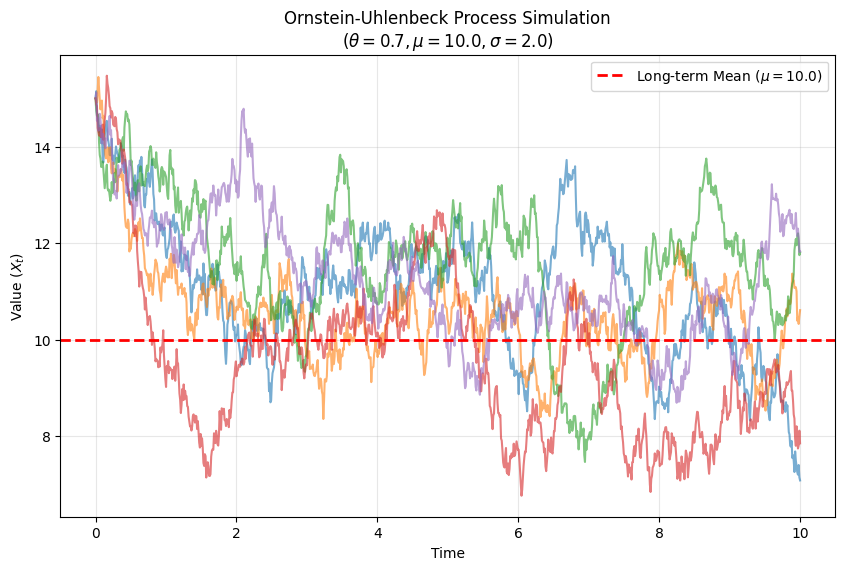

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ou_process(theta, mu, sigma, x0, dt, T, n_simulations=1):
    """
    模擬 Ornstein-Uhlenbeck 過程
    
    參數:
    theta (float): 均值回歸速度
    mu (float): 長期均值
    sigma (float): 波動率
    x0 (float): 初始值
    dt (float): 時間步長
    T (float): 總時間
    n_simulations (int): 模擬的路徑數量
    
    返回:
    time (array): 時間軸
    x (array): 模擬的路徑數據 (shape: [steps, n_simulations])
    """
    N = int(T / dt)  # 總步數
    time = np.linspace(0, T, N)
    
    # 初始化陣列
    x = np.zeros((N, n_simulations))
    x[0] = x0
    
    # 執行 Euler-Maruyama 迭代
    for t in range(1, N):
        # 上一時刻的值
        x_prev = x[t-1]
        
        # 產生隨機雜訊 (標準常態分佈)
        dw = np.random.normal(loc=0.0, scale=np.sqrt(dt), size=n_simulations)
        
        # 核心公式: dX = theta*(mu - X)*dt + sigma*dW
        dx = theta * (mu - x_prev) * dt + sigma * dw
        
        # 更新 X
        x[t] = x_prev + dx
        
    return time, x

# --- 設定參數 ---
theta = 0.7    # 回歸速度 (越大拉回越快)
mu = 10.0      # 長期均值 (目標值)
sigma = 2.0    # 波動率 (雜訊大小)
x0 = 15.0      # 初始值 (故意設得離 mu 遠一點，觀察回歸)
dt = 0.01      # 時間步長
T = 10.0       # 總時間

# --- 執行模擬 ---
# 模擬 5 條路徑以觀察隨機性
time_axis, ou_paths = simulate_ou_process(theta, mu, sigma, x0, dt, T, n_simulations=5)

# --- 繪圖 ---
plt.figure(figsize=(10, 6))
plt.plot(time_axis, ou_paths, alpha=0.6, lw=1.5)

# 畫出長期均值 mu 的虛線
plt.axhline(y=mu, color='r', linestyle='--', linewidth=2, label=f'Long-term Mean ($\mu={mu}$)')

plt.title(f'Ornstein-Uhlenbeck Process Simulation\n($\\theta={theta}, \mu={mu}, \sigma={sigma}$)')
plt.xlabel('Time')
plt.ylabel('Value ($X_t$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

Forward 終點 (t=2.0): 1.8335
Reverse 終點 (t=0): 4.9062 (原始值: 5.0)


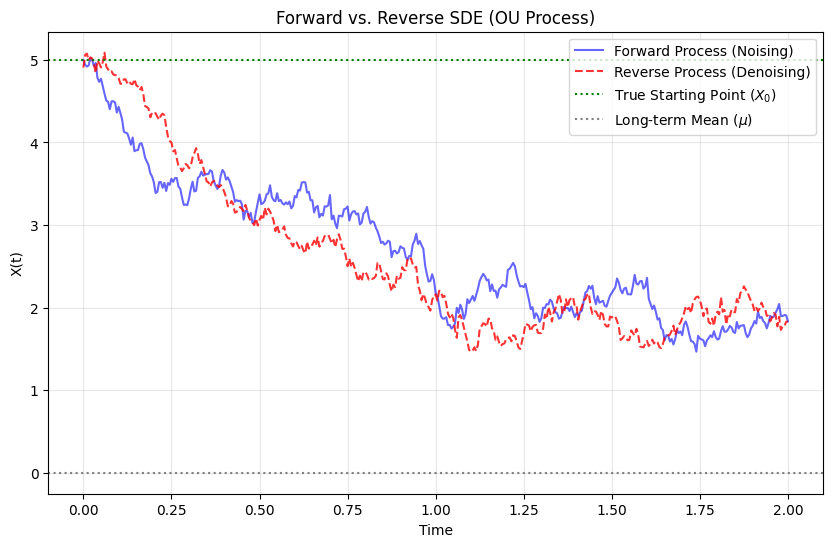

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def analytical_mean_var(t, x0, theta, mu, sigma):
    """計算 OU 過程在時間 t 的解析均值與變異數"""
    exp_theta_t = np.exp(-theta * t)
    mean_t = mu + (x0 - mu) * exp_theta_t
    # 防止 t=0 時除以零，雖然理論上 t=0 不會用到 score，但數值上需注意
    var_t = (sigma**2 / (2 * theta)) * (1 - exp_theta_t**2)
    return mean_t, var_t

def get_score(x, t, x0, theta, mu, sigma):
    """計算 Score Function: ∇ log p_t(x)"""
    mean_t, var_t = analytical_mean_var(t, x0, theta, mu, sigma)
    # 避免 var_t 為 0 (t=0 時)
    if var_t < 1e-5: 
        return 0 
    return -(x - mean_t) / var_t

# --- 參數設定 ---
theta = 1.0
mu = 0.0      # 設均值為 0 方便觀察
sigma = 1.0
x0_true = 5.0 # 初始值 (我們希望 Reverse 過程能走回這裡)
T = 2.0
dt = 0.005
N = int(T / dt)
t_axis = np.linspace(0, T, N+1)

# --- 1. Forward SDE (模擬數據生成/加噪) ---
# X_{t+1} = X_t + f(X,t)dt + g dW
x_fwd = np.zeros(N+1)
x_fwd[0] = x0_true

for i in range(N):
    t = t_axis[i]
    dt_step = dt
    dw = np.random.normal(0, np.sqrt(dt_step))
    
    drift = theta * (mu - x_fwd[i])
    diffusion = sigma
    
    x_fwd[i+1] = x_fwd[i] + drift * dt_step + diffusion * dw

print(f"Forward 終點 (t={T}): {x_fwd[-1]:.4f}")

# --- 2. Reverse SDE (模擬生成/去噪) ---
# 我們從 Forward 的終點開始，嘗試走回起點
# 公式: dX = [f(X) - sigma^2 * score] dt + sigma dW
# 注意: 這裡是「時間倒流」，所以 dt 在數值更新時取負號，或是公式調整
x_rev = np.zeros(N+1)
x_rev[-1] = x_fwd[-1] # 起點是 Forward 的終點

# 這裡我們使用 explicit looping from N-1 down to 0
for i in range(N-1, -1, -1):
    t_current = t_axis[i+1] # 當前時間是較晚的時間
    x_curr = x_rev[i+1]
    
    # 計算該時刻的 Score (需要用到已知的 x0_true 資訊來計算解析解)
    # 在實際 Diffusion Model 中，這部分是由神經網路 s_theta(x, t) 預測的
    score = get_score(x_curr, t_current, x0_true, theta, mu, sigma)
    
    # Reverse Drift: f(X) - sigma^2 * Score
    f_x = theta * (mu - x_curr)
    rev_drift = f_x - (sigma**2) * score
    
    # Euler-Maruyama Step (Reverse)
    # 這裡的 dt 視為負的步長 (-dt)，但布朗運動項的 scaling 仍是 sqrt(dt)
    # dX_bar = (f - sigma^2 score) * (-dt) + sigma * dW_bar
    dw = np.random.normal(0, np.sqrt(dt))
    
    x_rev[i] = x_curr - rev_drift * dt + sigma * dw

print(f"Reverse 終點 (t=0): {x_rev[0]:.4f} (原始值: {x0_true})")

# --- 繪圖比較 ---
plt.figure(figsize=(10, 6))
plt.plot(t_axis, x_fwd, label='Forward Process (Noising)', color='blue', alpha=0.6)
plt.plot(t_axis, x_rev, label='Reverse Process (Denoising)', color='red', linestyle='--', alpha=0.8)
plt.axhline(y=x0_true, color='green', linestyle=':', label='True Starting Point ($X_0$)')
plt.axhline(y=mu, color='gray', linestyle=':', label='Long-term Mean ($\mu$)')

plt.title('Forward vs. Reverse SDE (OU Process)')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


---

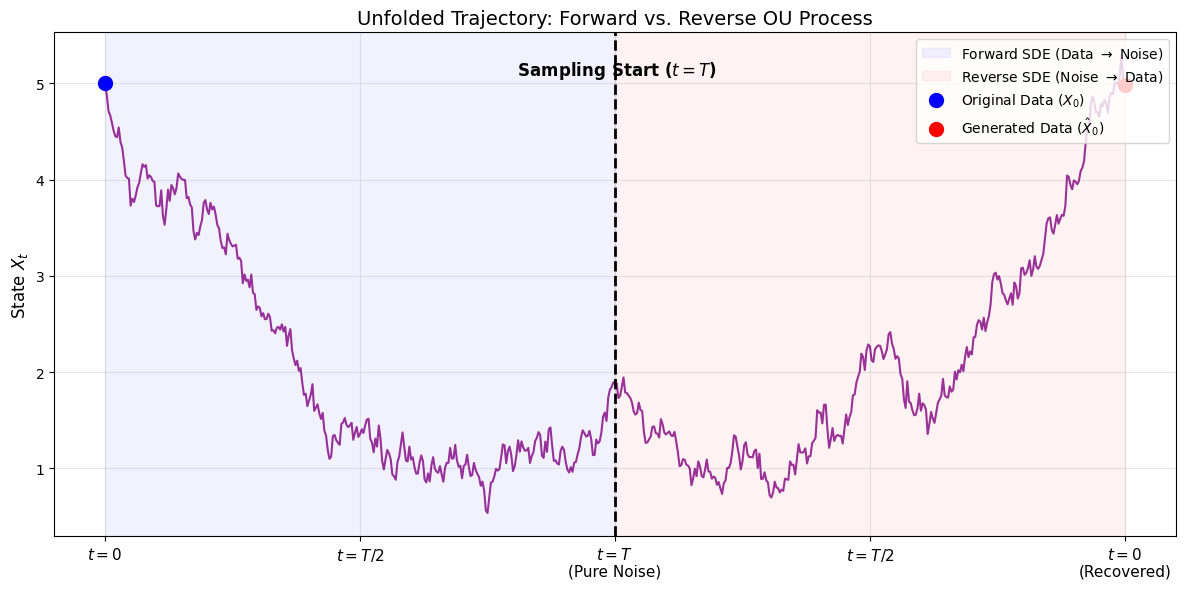

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 定義輔助函數 (與前次相同) ---
def analytical_mean_var(t, x0, theta, mu, sigma):
    """計算 OU 過程在時間 t 的解析均值與變異數"""
    exp_theta_t = np.exp(-theta * t)
    mean_t = mu + (x0 - mu) * exp_theta_t
    var_t = (sigma**2 / (2 * theta)) * (1 - exp_theta_t**2)
    return mean_t, var_t

def get_score(x, t, x0, theta, mu, sigma):
    """計算 Score Function: ∇ log p_t(x)"""
    mean_t, var_t = analytical_mean_var(t, x0, theta, mu, sigma)
    if var_t < 1e-5: return 0 
    return -(x - mean_t) / var_t

# --- 2. 參數與模擬 ---
theta = 1.0
mu = 0.0      
sigma = 1.0
x0_true = 5.0 
T = 3.0       # 拉長一點時間，讓收斂更明顯
dt = 0.01
N = int(T / dt)
t_axis = np.linspace(0, T, N+1)

# [Forward Pass]
x_fwd = np.zeros(N+1)
x_fwd[0] = x0_true
for i in range(N):
    dw = np.random.normal(0, np.sqrt(dt))
    x_fwd[i+1] = x_fwd[i] + theta*(mu - x_fwd[i])*dt + sigma*dw

# [Reverse Pass]
# 從 Forward 的終點開始，時間倒流
x_rev = np.zeros(N+1)
x_rev[-1] = x_fwd[-1] # 起點設為 Forward 的終點

for i in range(N-1, -1, -1):
    t_current = t_axis[i+1] 
    x_curr = x_rev[i+1]
    
    # 計算 Score
    score = get_score(x_curr, t_current, x0_true, theta, mu, sigma)
    
    # Reverse SDE 更新
    rev_drift = theta*(mu - x_curr) - (sigma**2)*score
    dw = np.random.normal(0, np.sqrt(dt))
    x_rev[i] = x_curr - rev_drift*dt + sigma*dw

# --- 3. 繪圖 (展開視圖) ---
plt.figure(figsize=(12, 6))

# 定義「展開後」的時間軸
# 左半邊: 0 ~ T
# 右半邊: T ~ 2T (用來表示從 T 倒數回 0 的過程)
global_time_axis = np.concatenate([t_axis, t_axis + T])

# 準備數據
# x_fwd: 正常順序 (0 -> T)
# x_rev: 需要反轉 (因為 array 索引 0 是 t=0，索引 -1 是 t=T)
# 我們希望畫圖順序是 T -> 0，所以要取 x_rev[::-1]
combined_trajectory = np.concatenate([x_fwd, x_rev[::-1]])

# 繪製軌跡
plt.plot(global_time_axis, combined_trajectory, color='purple', lw=1.5, alpha=0.8)

# 區分 Forward (藍色區域) 與 Reverse (紅色區域)
plt.axvspan(0, T, color='blue', alpha=0.05, label='Forward SDE (Data $\\to$ Noise)')
plt.axvspan(T, 2*T, color='red', alpha=0.05, label='Reverse SDE (Noise $\\to$ Data)')

# 中間的分隔線 (T)
plt.axvline(x=T, color='black', linestyle='--', linewidth=2)
plt.text(T, plt.ylim()[1]*0.95, ' Sampling Start ($t=T$)', ha='center', va='top', fontsize=12, fontweight='bold')

# 標示起點與終點
plt.scatter([0], [x0_true], color='blue', s=100, zorder=5, label='Original Data ($X_0$)')
plt.scatter([2*T], [x_rev[0]], color='red', s=100, zorder=5, label='Generated Data ($\hat{X}_0$)')

# 設定 X 軸標籤 (自定義刻度)
# 我們希望 X 軸顯示的是物理時間 t
ticks = [0, T/2, T, T + T/2, 2*T]
tick_labels = ['$t=0$', '$t=T/2$', '$t=T$\n(Pure Noise)', '$t=T/2$', '$t=0$\n(Recovered)']
plt.xticks(ticks, tick_labels, fontsize=11)

plt.title('Unfolded Trajectory: Forward vs. Reverse OU Process', fontsize=14)
plt.ylabel('State $X_t$', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- 1. 數學模型設定 ---
def get_marginal_params(t, mu_init, sigma_init, theta, mu_ou, sigma_ou):
    """計算時間 t 的邊際分佈參數 N(M_t, V_t)"""
    exp_term = np.exp(-theta * t)
   
    M_t = mu_ou + (mu_init - mu_ou) * exp_term
   
    V_t = (sigma_init**2) * (exp_term**2) + \
          (sigma_ou**2 / (2 * theta)) * (1 - exp_term**2)
    return M_t, V_t

def get_marginal_score(x, t, mu_init, sigma_init, theta, mu_ou, sigma_ou):
    """計算邊際 Score: ∇ log p_t(x)"""
    M_t, V_t = get_marginal_params(t, mu_init, sigma_init, theta, mu_ou, sigma_ou)
    if V_t < 1e-6: return np.zeros_like(x)
    return -(x - M_t) / V_t

# --- 2. 模擬參數 ---
n_sims = 200        # 粒子數
theta = 0.8
mu_ou = 0.0         # OU mu
sigma_ou = 1.5      # noise level

T = 4.0             # 總時間
dt = 0.01
steps = int(T / dt)
t_axis = np.linspace(0, T, steps+1)


mu_init = 5.0       
sigma_init = 0.5    # init sigma(標準差)
x_fwd = np.zeros((steps+1, n_sims))
x_fwd[0] = np.random.normal(mu_init, sigma_init, n_sims) ###<<<<< Normal dist.

for i in range(steps):
    # Vectorized Euler-Maruyama
    x_curr = x_fwd[i]
    drift = theta * (mu_ou - x_curr)
    diffusion = sigma_ou
    dw = np.random.normal(0, np.sqrt(dt), n_sims)
    x_fwd[i+1] = x_curr + drift * dt + diffusion * dw

# --- 4. Reverse SDE (Generative / Denoising) ---
x_rev = np.zeros((steps+1, n_sims))
x_rev[-1] = x_fwd[-1]

for i in range(steps-1, -1, -1):
    t_curr = t_axis[i+1] 
    x_curr = x_rev[i+1]
    
    # Marginal Score 
    score = get_marginal_score(x_curr, t_curr, mu_init, sigma_init, theta, mu_ou, sigma_ou)
    
    # Reverse SDE : dX = [f(X) - g^2 * score] * (-dt) + g * dW
    f_x = theta * (mu_ou - x_curr)
    g_sq_score = (sigma_ou**2) * score
    rev_drift = f_x - g_sq_score
    
    dw = np.random.normal(0, np.sqrt(dt), n_sims)
    # 更新
    x_rev[i] = x_curr - rev_drift * dt + sigma_ou * dw



C:\Users\user\AppData\Local\Temp\ipykernel_12912\2409417884.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


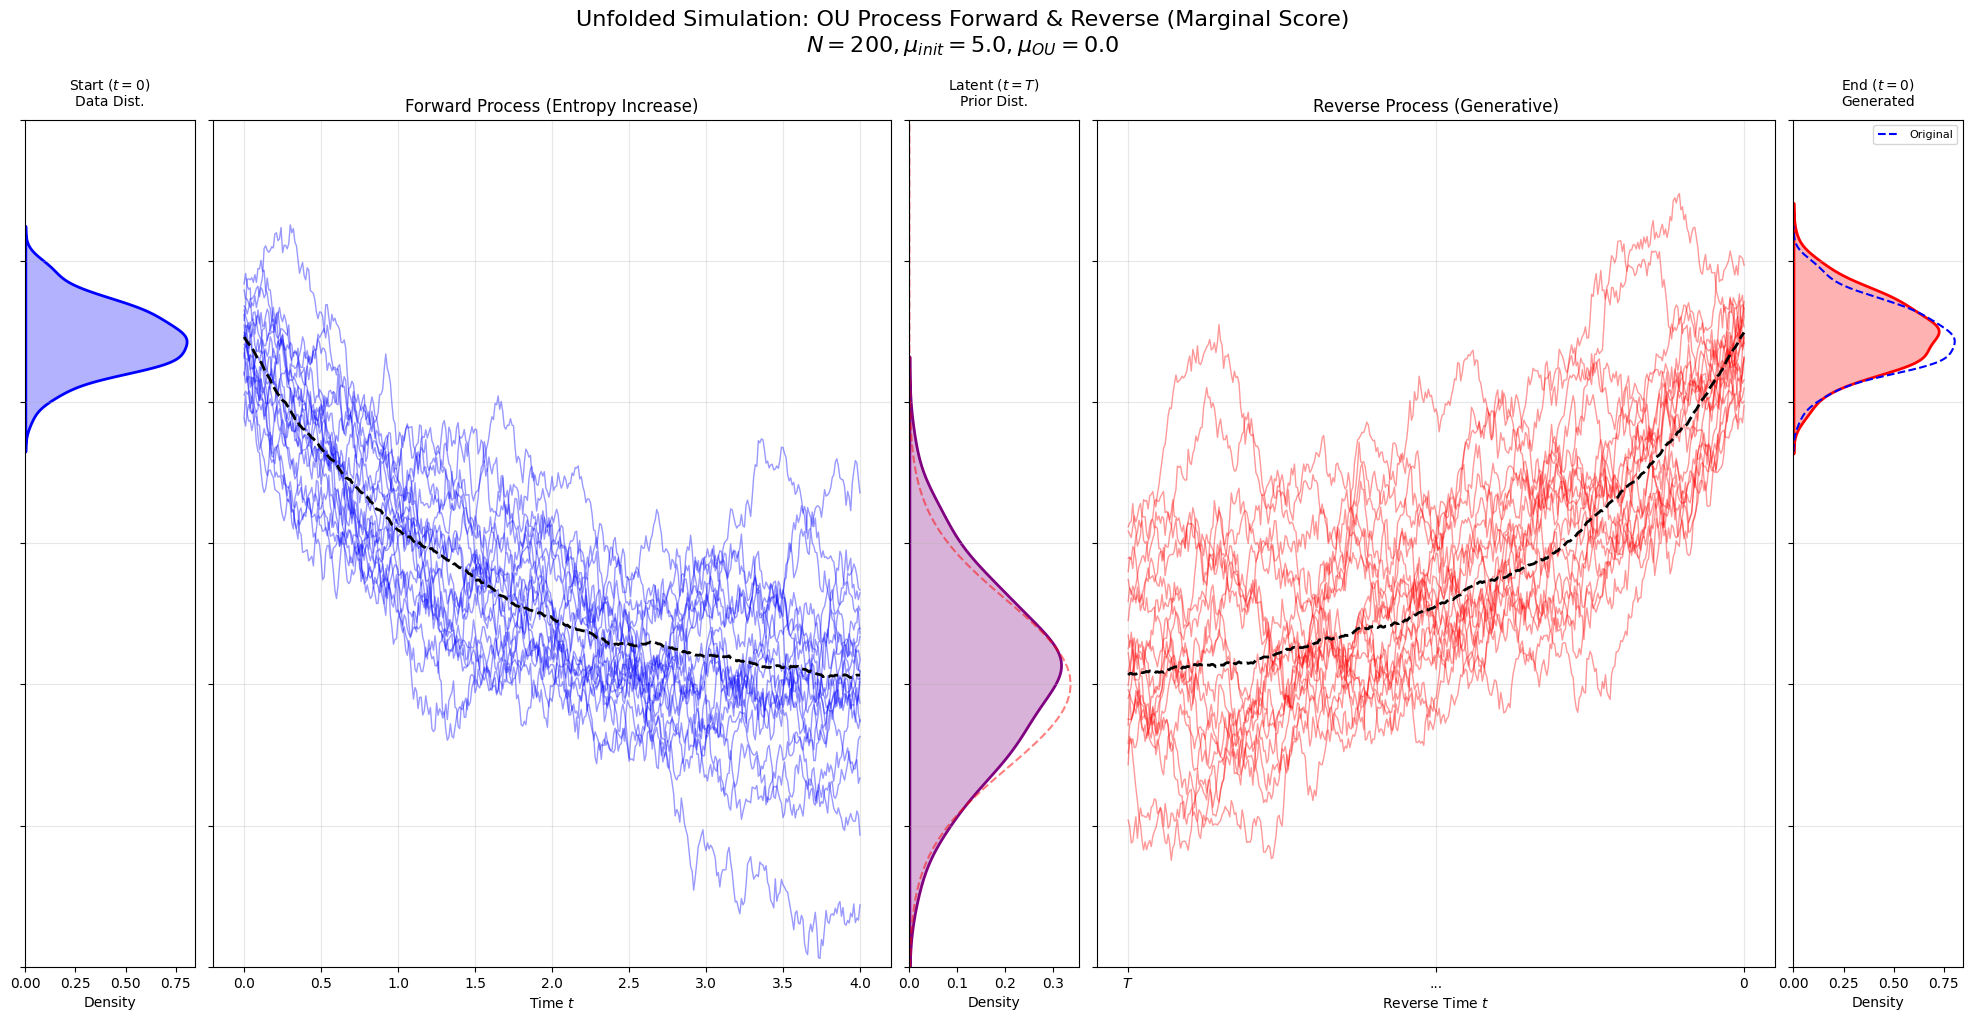

In [10]:
# --- 5. 進階視覺化 (GridSpec 佈局) ---
fig = plt.figure(figsize=(25, 11))

# 定義佈局: [PDF1] [Forward Paths] [PDF2] [Reverse Paths] [PDF3]
# width_ratios 控制每個區塊的寬度比例
gs = gridspec.GridSpec(1, 5, width_ratios=[1, 4, 1, 4, 1], wspace=0.05)

ax_pdf_start = plt.subplot(gs[0])
ax_fwd = plt.subplot(gs[1], sharey=ax_pdf_start)
ax_pdf_mid = plt.subplot(gs[2], sharey=ax_pdf_start)
ax_rev = plt.subplot(gs[3], sharey=ax_pdf_start)
ax_pdf_end = plt.subplot(gs[4], sharey=ax_pdf_start)

# 設定統一的 Y 軸範圍以便觀察
y_lims = (-4, 8)

# --- 繪圖函數 helper ---
def plot_pdf(ax, data, color, label, title):
    sns.kdeplot(y=data, ax=ax, color=color, fill=True, alpha=0.3, linewidth=2)
    ax.set_ylim(y_lims)
    ax.set_title(title, fontsize=10, pad=10)
    ax.set_xlabel("Density")
    ax.grid(True, axis='y', alpha=0.3)
    # 移除多餘的軸標籤使其乾淨
    if ax != ax_pdf_start:
        ax.set_yticklabels([])

def plot_paths(ax, time_axis, data, color, title, is_reverse=False):
    # 隨機選 20 條畫出來就好，不然太亂
    indices = np.random.choice(n_sims, 20, replace=False)
    for idx in indices:
        ax.plot(time_axis, data[:, idx], color=color, alpha=0.4, linewidth=1)
    
    # 畫出平均路徑
    ax.plot(time_axis, np.mean(data, axis=1), color='black', linestyle='--', linewidth=2, label='Sample Mean')
    
    ax.set_ylim(y_lims)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)
    if is_reverse:
        # Reverse 的 X 軸標籤要反過來顯示物理意義，但數據是連續接續的
        # 這裡為了簡單，我們畫圖時讓 X 軸延續，但標籤可以自定義
        pass

# 1. 最左邊 PDF (t=0, Initial)
plot_pdf(ax_pdf_start, x_fwd[0], 'blue', 'Initial', 'Start ($t=0$)\nData Dist.')

# 2. Forward Paths (0 -> T)
plot_paths(ax_fwd, t_axis, x_fwd, 'blue', 'Forward Process (Entropy Increase)')
ax_fwd.set_xlabel('Time $t$')

# 3. 中間 PDF (t=T, Latent/Noise)
# 畫出理論的 OU 穩態分佈作為參考 (紅色虛線)
y_grid = np.linspace(*y_lims, 100)
steady_var = sigma_ou**2 / (2*theta)
steady_pdf = (1/np.sqrt(2*np.pi*steady_var)) * np.exp(-(y_grid - mu_ou)**2 / (2*steady_var))
ax_pdf_mid.plot(steady_pdf, y_grid, 'r--', alpha=0.5, label='Theoretical\nStationary')
plot_pdf(ax_pdf_mid, x_fwd[-1], 'purple', 'Latent', 'Latent ($t=T$)\nPrior Dist.')
# ax_pdf_mid.legend(fontsize=8)

# 4. Reverse Paths (T -> 0)
# 為了視覺上的連貫性，我們將時間軸平移: T -> 2T
reversed_time_axis = t_axis + T 
# 數據需要反轉順序畫 (因為 x_rev 索引 0 是 t=0_rec, 索引 -1 是 t=T)
# 但我們的 x_rev 存儲方式是: index 0 = t=0(結果), index -1 = t=T(起點)
# 為了符合「從左到右」的時間流，我們把 x_rev 倒過來畫
plot_paths(ax_rev, reversed_time_axis, x_rev[::-1], 'red', 'Reverse Process (Generative)')
ax_rev.set_xlabel('Reverse Time $t$')
# 修改 X 軸刻度顯示
xticks = [T, T + T/2, 2*T]
xticklabels = ['$T$', '...', '$0$']
ax_rev.set_xticks(xticks)
ax_rev.set_xticklabels(xticklabels)

# 5. 最右邊 PDF (t=0, Recovered)
plot_pdf(ax_pdf_end, x_rev[0], 'red', 'Recovered', 'End ($t=0$)\nGenerated')
# 把最左邊的原始分佈也畫上去比對 (藍色虛線)
sns.kdeplot(y=x_fwd[0], ax=ax_pdf_end, color='blue', linestyle='--', linewidth=1.5, label='Original')
ax_pdf_end.legend(fontsize=8, loc='upper right')

plt.suptitle(f"Unfolded Simulation: OU Process Forward & Reverse (Marginal Score)\n$N={n_sims}, \\mu_{{init}}={mu_init}, \\mu_{{OU}}={mu_ou}$", fontsize=16)
plt.tight_layout()
plt.show()
